# An Analysis of Programming Language Popularity and Developer Preference
## Based on the 2020-2024 Stack Overflow Developer Surveys

This Jupyter notebook supports the research paper titled
**"AN ANALYSIS OF PROGRAMMING LANGUAGE POPULARITY AND DEVELOPER PREFERENCE IN THE 2020-2024 STACK OVERFLOW DEVELOPER SURVEYS"**

### Research Objectives:

The objective of this analysis is to examine how programming language popularity and developer preference have changed between 2020 and 2024. The analysis focuses on data collected from the annual Stack Overflow Developer Surveys and evaluates trends using four key metrics:

- **Usage**: Percentage of respondents who reported using a language in the current survey year
- **Desired**: Percentage of respondents who indicated that they want to learn or adopt a programming language in the following year.
- **Loved/Admired**: Percentage of respondents who reported using a programming language in the current survey year and also indicated that they want to continue using it in the following year.

Through descriptive statistics and trend analysis, this notebook aims to identify patterns of growth, stability, or decline in programming languages over the five-year period and to support the findings discussed in Chapter IV of the research paper.

## Data Source and Scope

The data used in this analysis were obtained from the **Stack Overflow Developer Survey** conducted annually from **2020-2024**. The Stack Overflow Developer Survey is a large-scale, global survey that collects responses from tens of thousands of developers each year, covering a wide range of topics related to software development.

The datasets used in this notebook are publicly available and include self-reported information on programming language usage and developer preferences.

### Scope of the Data
- The analysis focuses **only on programming languages**
- Other survey categories such as frameworks, databases, and tools are excluded
- The study analyzes survey responses from 2020 through 2024

### Metrics Analyzed
The following metrics are examined:
- **Usage**: Percentage of respondents who reported using a language in the current survey year
- **Desired**: Percentage of respondents who indicated that they want to learn or adopt a programming language in the following year.
- **Loved/Admired**: Percentage of respondents who reported using a programming language in the current survey year and also indicated that they want to continue using it in the following year.

### Limitations
- Survey data is self-reported and may reflect respondent bias
- The number of survey respondents varies by year

These limitations are considered when interpreting the results of the analysis.

## Imports and Global Configuration

In [1]:
# Standard library
import sys
from pathlib import Path

# Add project source directory to Python path for local module imports
sys.path.append(str(Path("..").resolve() / "src"))

# Third-party libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Local project imports
import metrics
import helpers
import plotting

In [2]:
# List of survey years to analyze
YEARS = [2020, 2021, 2022, 2023, 2024]

# Languages and tools excluded from analysis
EXCLUDED_LANGUAGES = {
    "Node.js",
    "HTML/CSS"
}

## Data Loading

This section loads the Stack Overflow Developer Survey datasets for the years 2020 to 2024.
Each dataset contains survey responses from developers around the world, including information about the programming languages they use and their preferences.

For consistency and ease of analysis, the datasets from all five years are loaded and combined into a single data structure. A new column indicating the survey year is added to each dataset so that changes over time can be analyzed in later sections.

In [3]:
# Dictionary to store each year's dataset
survey_data = {}

# Loads csv into the dictionary

for year in YEARS:
    file_path = f"../data/survey_{year}.csv"
    df = pd.read_csv(file_path)
    df["Year"] = year
    survey_data[year] = df

In [4]:
# Prints out number of rows and columns in each dataset

for year, df in survey_data.items():
    print(f"{year}: {df.shape}")

2020: (64461, 62)
2021: (83439, 49)
2022: (73268, 80)
2023: (89184, 85)
2024: (65437, 115)


## Data Cleaning and Preparation

Before analysis can be performed, the survey data must be cleaned and prepared to ensure consistency across all years. The Stack Overflow Developer Survey records programming language data as semicolon-separated text values, and some responses contain missing data.

In [5]:
# List of columns relevant to this analysis
RELEVANT_COLUMNS = ["Year", "LanguageHaveWorkedWith", "LanguageWantToWorkWith"]

# Only keeps relevant columns in the datasets
for year, df in survey_data.items():
    survey_data[year] = df[[column for column in RELEVANT_COLUMNS if column in df.columns]]

## Metric Calculation by Year

The following metrics are examined:
- **Usage**: Percentage of respondents who reported using a language in the current survey year
- **Desired**: Percentage of respondents who indicated that they want to learn or adopt a programming language in the following year.
- **Loved/Admired**: Percentage of respondents who reported using a programming language in the current survey year and also indicated that they want to continue using it in the following year.

### Usage

**Percentage Usage Formula:**

$$
\text{Usage}_{L,y} = \frac{n_{L,y}}{N_y} \times 100
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ N_{y} $ = Total number of respondents in year $ y $
- $ n_{L, y} $ = Number of respondents who reported using language $ L $ in year $ y $


In [6]:
usage_by_year = {}
usage_column = "LanguageHaveWorkedWith"

for year, df in survey_data.items():
    usage_by_year[year] = metrics.calculate_multiselect_percentage(df, usage_column, EXCLUDED_LANGUAGES)

### Desired

**Percentage Desired Formula:**

$$
\text{Desired}_{L,y} = \frac{w_{L,y}}{N_y} \times 100
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ N_{y} $ = Total number of respondents in year $ y $
- $ w_{L, y} $ = Number of respondents who indicated that they want to work with language $ L $ next year

In [7]:
desired_by_year = {}
desired_column = "LanguageWantToWorkWith"

for year, df in survey_data.items():
    desired_by_year[year] = metrics.calculate_multiselect_percentage(df, desired_column, EXCLUDED_LANGUAGES)

### Loved/Admired

**Percentage Admired Formula:**

$$
\text{Admired}_{L,y} = \frac{\lvert W_{L,y} \cap U_{L,y} \rvert}{\lvert U_L,y \rvert} \times 100
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ N_{y} $ = Total number of respondents in year $ y $
- $ W_{L,y} $ = Set of respondents who indicated that they want to work with language $ L $ next year
- $ U_{L,y} $ = Set of respondents who reported using language $ L $ in survey year $ y $

In [8]:
admired_by_year = {}
admired_column = "LanguageWantToWorkWith"

for year, df in survey_data.items():
    admired_by_year[year] = metrics.calculate_admired_percentage(
        df, excluded_languages=EXCLUDED_LANGUAGES
    )

## Trend Table Construction

### Usage Trends

In [9]:
# Create usage trends dataframe containing 5 years of usage
usage_trends_df = helpers.generate_metric_trends(usage_by_year)

In [10]:
display(
    usage_trends_df
    .sort_values(by=YEARS[-1], ascending=False)
    .round(2)
    .reset_index(drop=True)
    .assign(Rank=lambda df: df.index + 1)
    .set_index("Rank")
)

,Language,2020,2021,2022,2023,2024
Rank,,,,,,
1,JavaScript,67.66,65.07,65.44,63.93,62.75
2,Python,44.07,48.32,48.12,49.53,51.42
3,SQL,54.75,47.15,49.49,48.91,51.35
4,TypeScript,25.41,30.25,34.87,39.06,38.75
5,Bash/Shell (all shells),33.08,27.18,29.10,32.54,34.17
6,Java,40.21,35.41,33.31,30.71,30.53
7,C#,31.44,27.91,28.01,27.76,27.31
8,C++,23.89,24.35,22.58,22.53,23.14
9,C,21.76,21.04,19.29,19.44,20.39


### Desired Trends

In [11]:
# Create desired trends dataframe containing 5 years of usage
desired_trends_df = helpers.generate_metric_trends(desired_by_year)

In [12]:
display(
    desired_trends_df
    .sort_values(by=YEARS[-1], ascending=False)
    .round(2)
    .reset_index(drop=True)
    .assign(Rank=lambda df: df.index + 1)
    .set_index("Rank")
)

,Language,2020,2021,2022,2023,2024
Rank,,,,,,
1,Python,49.31,45.47,43.79,43.01,44.93
2,JavaScript,48.40,48.17,47.07,43.35,42.64
3,SQL,36.90,34.67,37.01,36.67,40.18
4,TypeScript,31.69,35.02,38.86,39.97,36.30
5,Rust,19.52,20.65,25.53,33.09,30.91
6,Go,23.29,20.55,23.13,22.29,24.82
7,Bash/Shell (all shells),21.67,18.28,19.76,22.65,24.65
8,C#,25.27,23.43,23.40,23.04,23.18
9,C++,18.03,19.85,17.75,17.63,19.50


### Loved/Admired Trends

In [13]:
# Create admired trends dataframe containing 5 years of usage
admired_trends_df = helpers.generate_metric_trends(admired_by_year)

In [14]:
display(
    admired_trends_df
    .sort_values(by=YEARS[-1], ascending=False)
    .round(2)
    .reset_index(drop=True)
    .assign(Rank=lambda df: df.index + 1)
    .set_index("Rank")
)

,Language,2020,2021,2022,2023,2024
Rank,,,,,,
1,Rust,89.69,90.12,89.70,88.52,84.94
2,Elixir,NaN,75.69,78.97,76.88,79.98
3,Zig,NaN,NaN,NaN,75.91,76.88
4,TypeScript,71.37,77.76,77.42,76.89,73.90
5,SQL,60.37,66.39,67.97,69.38,72.11
6,Python,70.86,72.23,70.94,70.11,71.75
7,Clojure,NaN,84.50,77.70,71.96,71.69
8,Go,65.94,66.85,67.58,66.62,71.49
9,C#,63.96,67.06,67.53,68.51,68.97


## Descriptive Statistics and Summary Measures

#### Measures Formulas

**Mean Across All Years:**

$$
\overline{\text{Metric}}_L = \frac{1}{Y} \sum_{y=1}^{Y} \text{Metric}_{L,y}
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ Y $ = Total number of survey years (here, $ Y = 5 $)

**Four-Year Change in Usage**

$$
\Delta_{y_0, y_Y} \text{Metric}_L = \text{Metric}_{L,y_0} - \text{Metric}_{L,y_Y}
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ Y $ = Total number of survey years (here, $ Y = 5 $)
- $ y_0 $ = The first survey year (here, $ y_0 = 2020 $)
- $ y_Y $ = The last survey year (here, $ y_Y = 2024 $)
- $ \Delta_{y_0, y_Y} \text{Metric}_L $ = Total change in metric of language $ L $ from $ y_0 $ (2020) to $ y_Y $ (2024)

**Average Annual Change in Usage**

$$
\overline{\Delta \text{Metric}}_L = \frac{\Delta_{y_0, y_Y} \text{Metric}_L}{Y - 1}
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ Y $ = Total number of survey years (here, $ Y = 5 $)
- $ y_0 $ = The first survey year (here, $ y_0 = 2020 $)
- $ y_Y $ = The last survey year (here, $ y_Y = 2024 $)
- $ \overline{\Delta \text{Metric}}_L $ = Average annual change in metric of language $ L $ from $ y_0 $ (2020) to $ y_Y $ (2024)

**Relative Change in Usage**

$$
\Delta^{rel} \text{Metric}_L = \frac{\Delta_{y_0, y_Y} \text{Metric}_L}{\text{Metric}_{L, y_0}} \times 100
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ Y $ = Total number of survey years (here, $ Y = 5 $)
- $ y_0 $ = The first survey year (here, $ y_0 = 2020 $)
- $ y_Y $ = The last survey year (here, $ y_Y = 2024 $)
- $ \Delta^{rel} \text{Metric}_L $ = Relative Change in metric of language $ L $ from $ y_0 $ (2020) to $ y_Y $ (2024)

### Usage Measures

In [15]:
# Create measures dataframe with Language as index
usage_measures_df = helpers.generate_measures_df("Usage", usage_trends_df)

In [16]:
display(
    usage_measures_df
    .sort_values(by="Mean Usage", ascending=False)
    .round(2)
)

,Mean Usage,4-year Change,Annual Change,Relative Change (%)
Language,,,,
JavaScript,64.97,-4.91,-1.23,-7.25
SQL,50.33,-3.39,-0.85,-6.20
Python,48.29,7.35,1.84,16.67
Java,34.03,-9.69,-2.42,-24.09
TypeScript,33.67,13.34,3.34,52.51
Bash/Shell (all shells),31.21,1.09,0.27,3.28
C#,28.49,-4.13,-1.03,-13.13
C++,23.30,-0.75,-0.19,-3.12
PHP,21.21,-7.83,-1.96,-29.92


### Desired Measures

In [17]:
# Create measures dataframe with Language as index
desired_measures_df = helpers.generate_measures_df("Desired", desired_trends_df)

In [18]:
display(
    desired_measures_df
    .sort_values(by="Mean Desired", ascending=False)
    .round(2)
)

,Mean Desired,4-year Change,Annual Change,Relative Change (%)
Language,,,,
JavaScript,45.93,-5.75,-1.44,-11.89
Python,45.30,-4.38,-1.10,-8.89
SQL,37.09,3.27,0.82,8.87
TypeScript,36.37,4.61,1.15,14.54
Rust,25.94,11.39,2.85,58.34
C#,23.66,-2.09,-0.52,-8.28
Go,22.82,1.52,0.38,6.55
Bash/Shell (all shells),21.40,2.98,0.74,13.74
Java,20.76,-5.38,-1.34,-21.94


### Loved/Admired Measures

In [19]:
# Create measures dataframe with Language as index
admired_measures_df = helpers.generate_measures_df("Admired", admired_trends_df)

In [20]:
display(
    admired_measures_df
    .sort_values(by="Mean Admired", ascending=False)
    .round(2)
)

,Mean Admired,4-year Change,Annual Change,Relative Change (%)
Language,,,,
Rust,88.59,-4.75,-1.19,-5.30
Elixir,77.88,NaN,NaN,NaN
Clojure,76.46,NaN,NaN,NaN
Zig,76.39,NaN,NaN,NaN
TypeScript,75.47,2.52,0.63,3.53
Raku,75.00,NaN,NaN,NaN
Python,71.18,0.89,0.22,1.25
Julia,70.53,-4.64,-1.16,-6.62
Go,67.70,5.55,1.39,8.41


## Derived Metrics

### Admired-Desired Distance

**Admired-Desired Distance Formula:**

$$
d_{L, y} = Admired_{L, y} - Desired_{L, y}
$$

Where:

- $ d_{L, y} $ = The distance between admired and desired of language $ L $ in survey year $ y $

In [21]:
AD_distance_trends_df = admired_trends_df.set_index("Language")[YEARS] - desired_trends_df.set_index("Language")[YEARS]

In [22]:
display(
    AD_distance_trends_df
    .sort_values(by=YEARS[-1], ascending=False)
    .round(2)
)

,2020,2021,2022,2023,2024
Language,,,,,
Elixir,NaN,71.30,74.07,72.07,74.79
Zig,NaN,NaN,NaN,71.39,70.26
Clojure,NaN,81.36,74.81,69.59,69.31
GDScript,NaN,NaN,NaN,64.00,64.41
Julia,67.00,71.20,73.22,63.54,63.16
Swift,53.73,60.61,59.63,60.48,61.65
Zephyr,NaN,NaN,NaN,NaN,60.90
Erlang,NaN,56.73,56.49,56.87,59.51
Lisp,NaN,57.33,58.24,55.75,57.56


**Mean Admired-Desired Distance Formula:**

$$
\overline{d}_L = \frac{1}{Y} \sum_{y=1}^{Y} \text{d}_{L,y}
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ Y $ = Total number of survey years (here, $ Y = 5 $)

In [23]:
mean_AD_distance_df = AD_distance_trends_df.mean(axis="columns")

In [24]:
display(
    mean_AD_distance_df
    .sort_values(ascending=False)
    .round(2)
)

Language
Raku                       74.65
Clojure                    73.77
Elixir                     73.06
Zig                        70.83
Julia                      67.62
GDScript                   64.21
Rust                       62.65
Zephyr                     60.90
APL                        60.62
F#                         60.10
Swift                      59.22
Erlang                     57.40
Lisp                       57.22
Delphi                     56.89
Dart                       55.89
Nim                        55.41
Solidity                   54.32
Crystal                    54.06
OCaml                      52.38
Kotlin                     51.74
Haskell                    51.18
Apex                       50.98
Scala                      50.72
MicroPython                50.01
Ada                        47.20
Ruby                       45.91
Lua                        45.14
Go                         44.88
C#                         43.54
SAS                        41.38
B

### Usage-Desired Distance

**Usage-Desired Distance Formula:**

$$
d_{L, y} = Usage{L, y} - Desired_{L, y}
$$

Where:

- $ d_{L, y} $ = The distance between usage and desired of language $ L $ in survey year $ y $

In [25]:
UD_distance_trends_df = usage_trends_df.set_index("Language")[YEARS] - desired_trends_df.set_index("Language")[YEARS]

In [26]:
display(
    UD_distance_trends_df
    .sort_values(by=YEARS[-1], ascending=False)
    .round(2)
)

,2020,2021,2022,2023,2024
Language,,,,,
JavaScript,19.27,16.89,18.36,20.58,20.11
Java,15.70,12.99,13.40,12.88,11.39
SQL,17.84,12.49,12.49,12.24,11.18
Bash/Shell (all shells),11.41,8.90,9.35,9.89,9.51
PHP,13.02,10.49,9.96,8.75,8.03
Python,-5.24,2.85,4.33,6.51,6.49
PowerShell,NaN,4.40,5.07,6.05,6.25
C,10.51,8.41,7.57,7.01,5.55
C#,6.17,4.48,4.62,4.73,4.14


**Mean Usage-Desired Distance Formula:**

$$
\overline{d}_L = \frac{1}{Y} \sum_{y=1}^{Y} \text{d}_{L,y}
$$

Where:

- $ L $ = Programming language
- $ y $ = Survey year
- $ Y $ = Total number of survey years (here, $ Y = 5 $)

In [27]:
mean_UD_distance_df = UD_distance_trends_df.mean(axis="columns")

In [28]:
display(
    mean_UD_distance_df
    .sort_values(ascending=False)
    .round(2)
)

Language
JavaScript                 19.04
Java                       13.27
SQL                        13.25
PHP                        10.05
Bash/Shell (all shells)     9.81
C                           7.81
PowerShell                  5.44
C#                          4.83
C++                         4.75
VBA                         3.08
Python                      2.99
MATLAB                      2.47
Visual Basic (.Net)         2.44
Groovy                      1.75
Objective-C                 1.08
Perl                        1.01
Assembly                    0.85
Delphi                      0.79
Lua                         0.61
Fortran                     0.27
Ruby                        0.22
Prolog                      0.15
Apex                        0.11
Cobol                       0.10
SAS                         0.05
Flow                        0.02
Ada                        -0.07
Zephyr                     -0.14
Raku                       -0.17
APL                        -0.18
R

## Charts

### Trend Line Charts

#### Usage Trends of Top Programming Languages

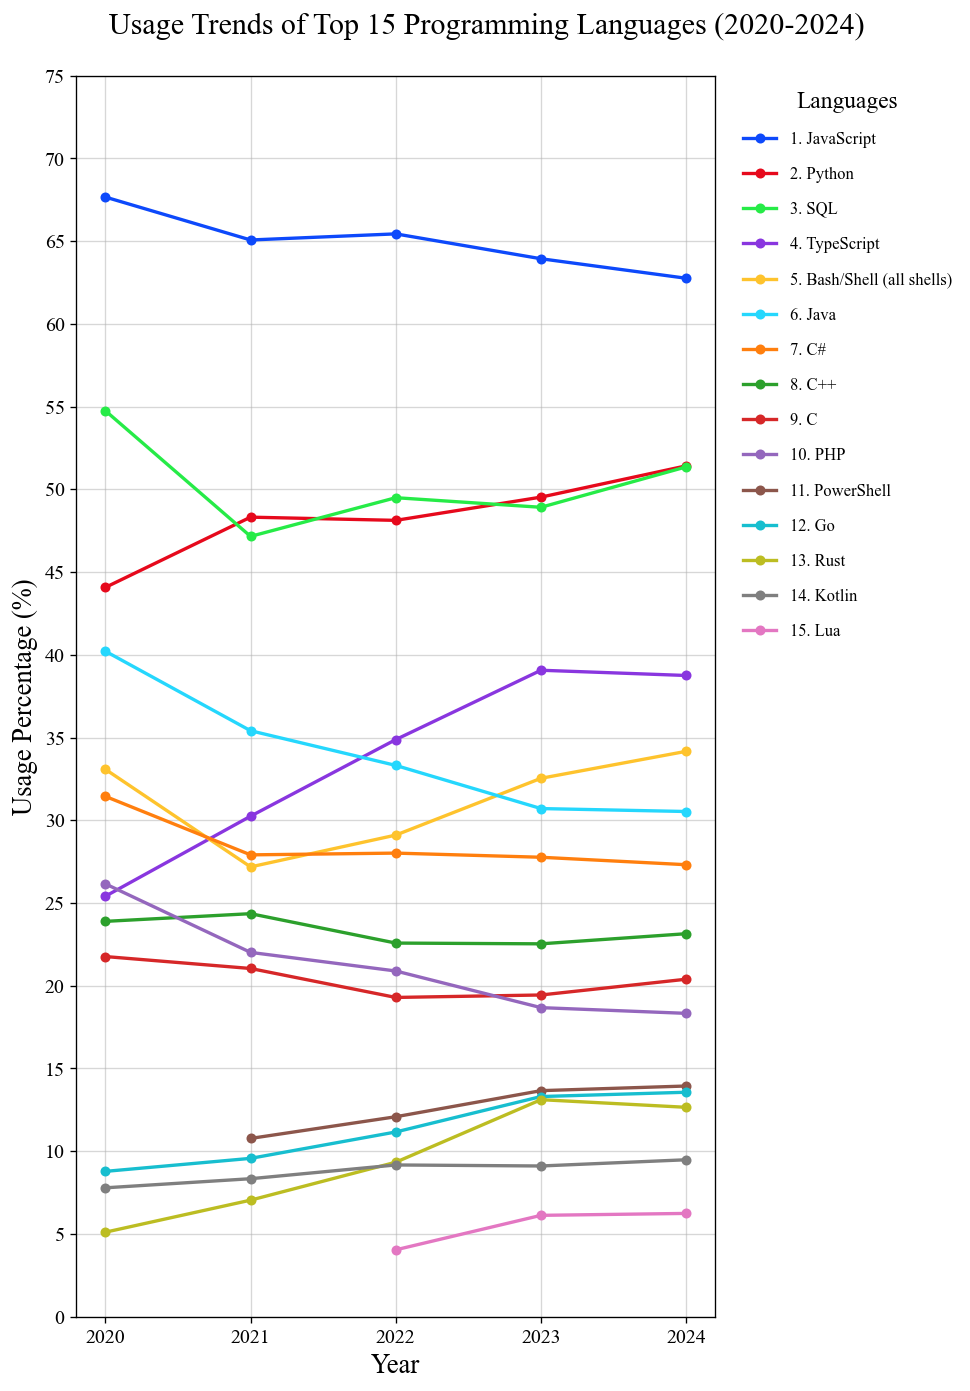

In [29]:
plotting.plot_line_chart_top_languages_trends(
    usage_trends_df,
    metric_name="Usage",
    top_n=15,
    y_min=0,
    y_max=75
)

#### Desired Trends of Top Programming Languages

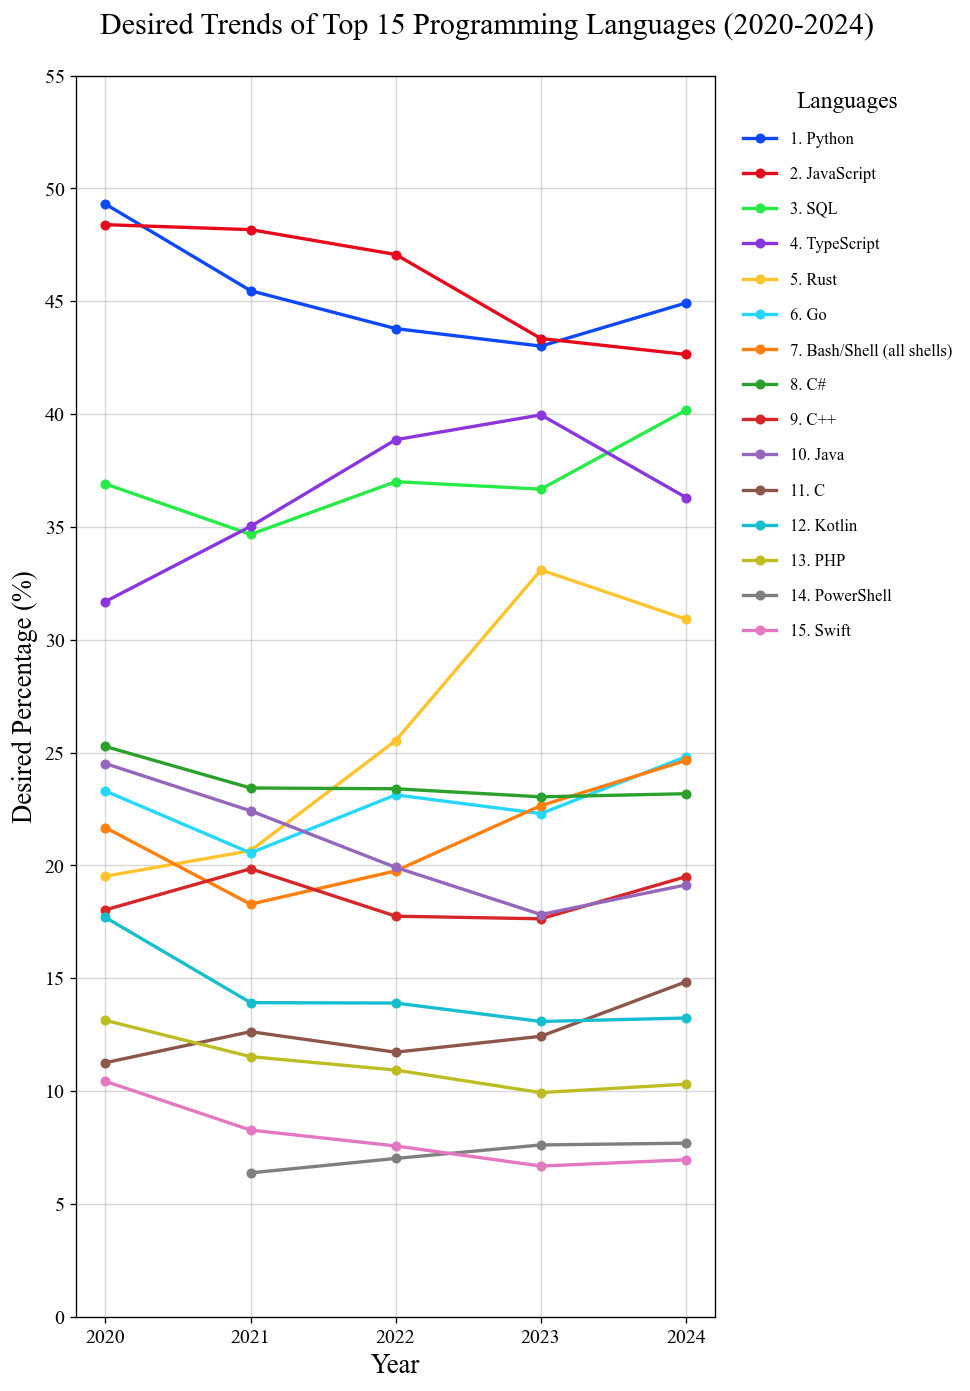

In [30]:
plotting.plot_line_chart_top_languages_trends(
    desired_trends_df,
    metric_name="Desired",
    top_n=15,
    y_min=0,
    y_max=55
)

#### Loved/Admired Trends of Top Programming Languages

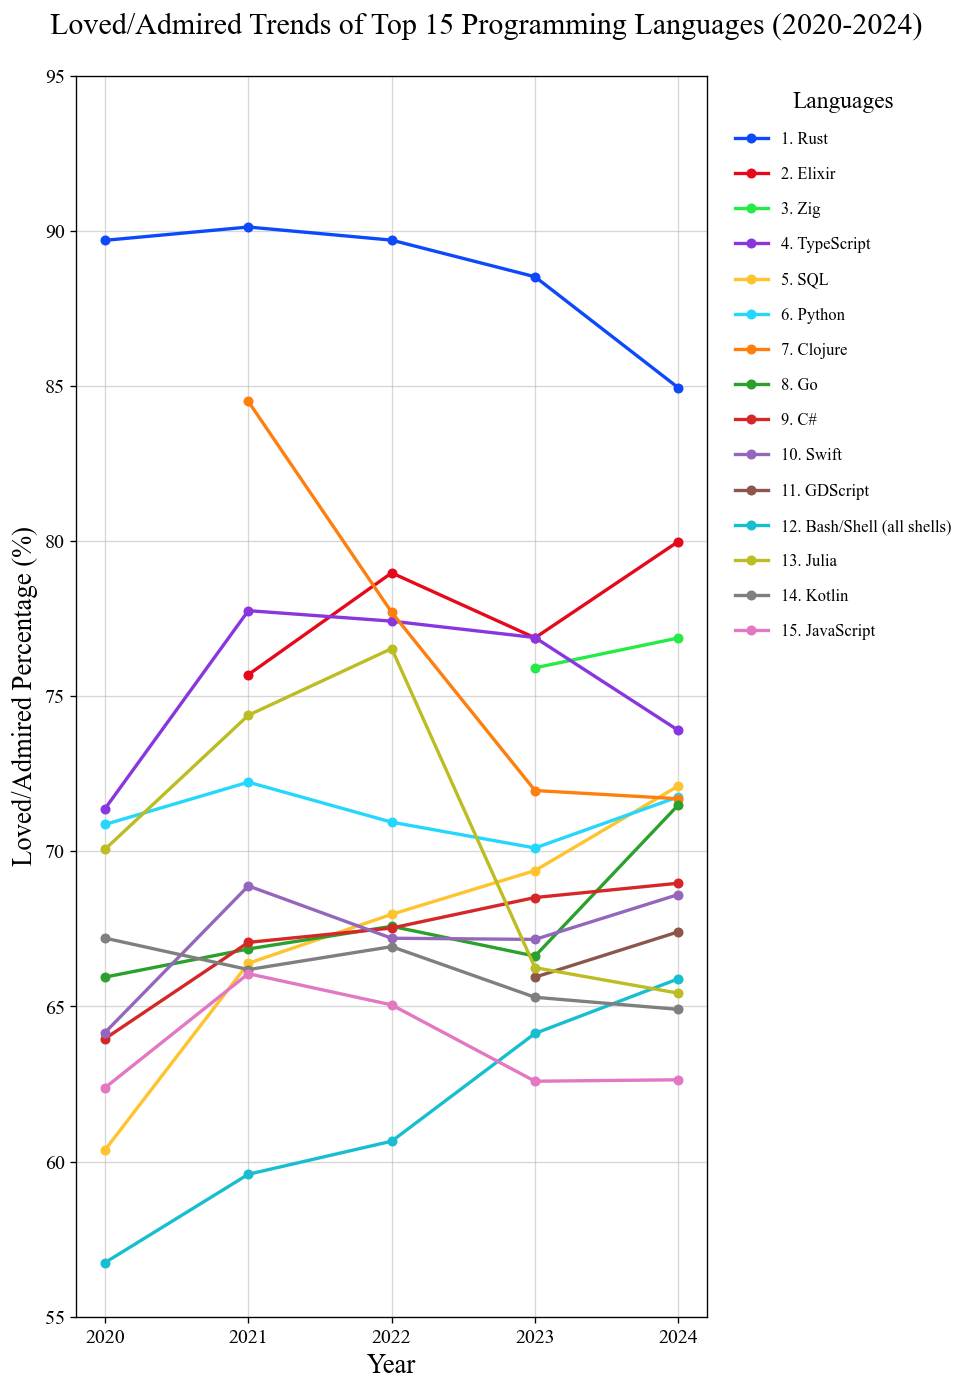

In [31]:
plotting.plot_line_chart_top_languages_trends(
    admired_trends_df,
    metric_name="Loved/Admired",
    top_n=15,
    y_min=55,
    y_max=95
)

### Change Bar Charts

#### Usage Change of Top Programming Languages

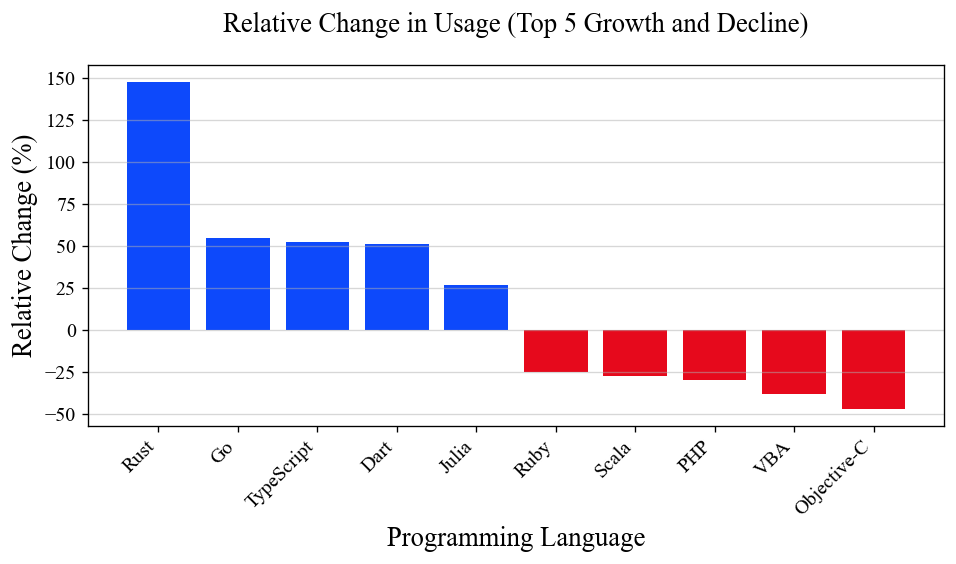

In [32]:
plotting.plot_relative_growth_bar_chart(
    usage_measures_df,
    metric_name="Usage",
    top_n=5
)


#### Desired Change of Top Programming Languages

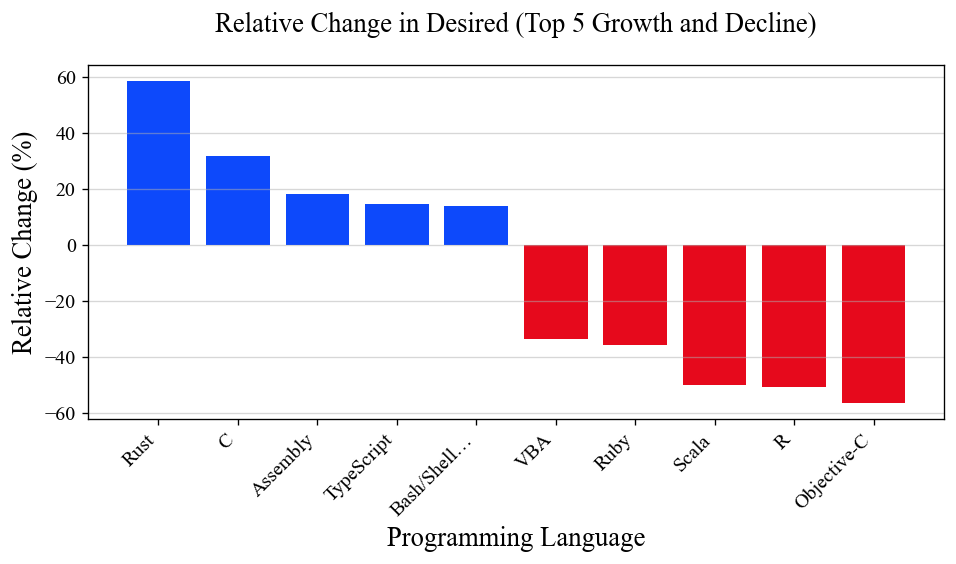

In [33]:
plotting.plot_relative_growth_bar_chart(
    desired_measures_df,
    metric_name="Desired",
    top_n=5
)

#### Loved/Admired Change of Top Programming Languages

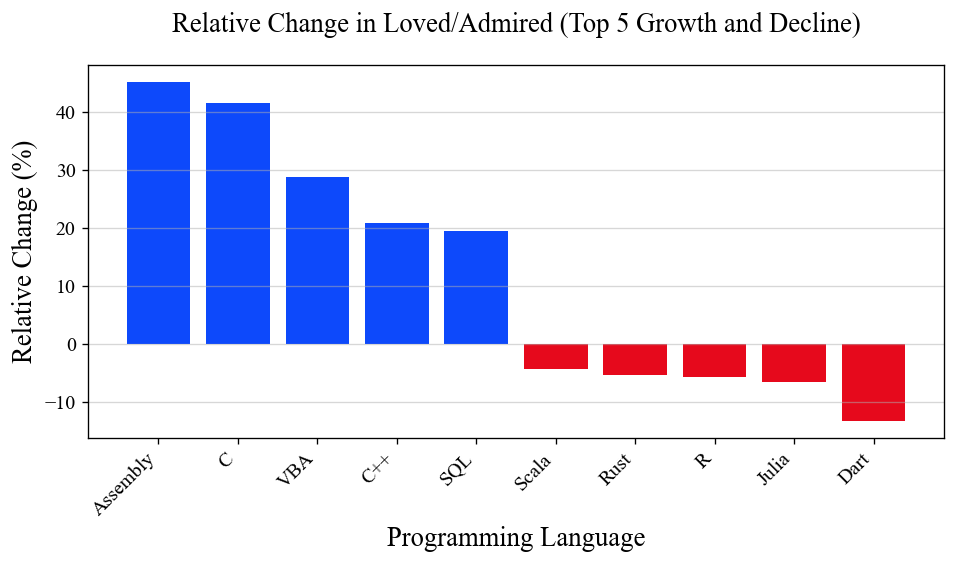

In [34]:
plotting.plot_relative_growth_bar_chart(
    admired_measures_df,
    metric_name="Loved/Admired",
    top_n=5
)

### Individual Language Trend Line Charts

#### Usage Trends

In [35]:
top_usage_positive = (
    usage_measures_df["Relative Change (%)"]
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_usage_negative = (
    usage_measures_df["Relative Change (%)"]
    .sort_values()
    .head(5)
    .index
)


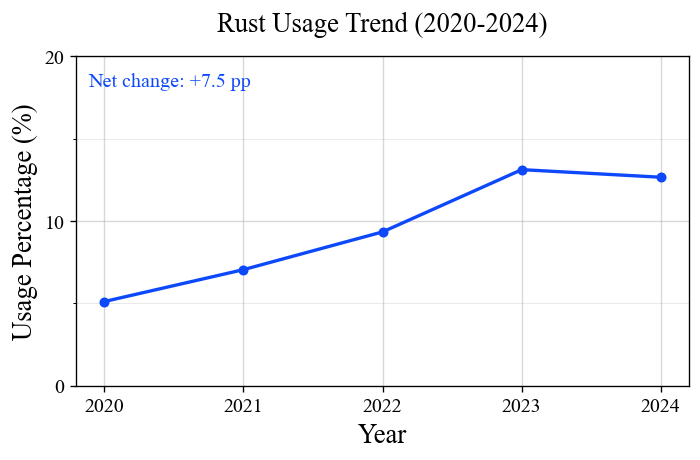

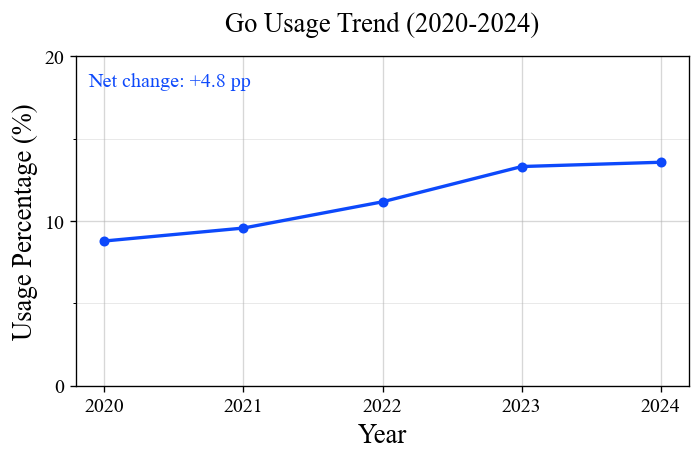

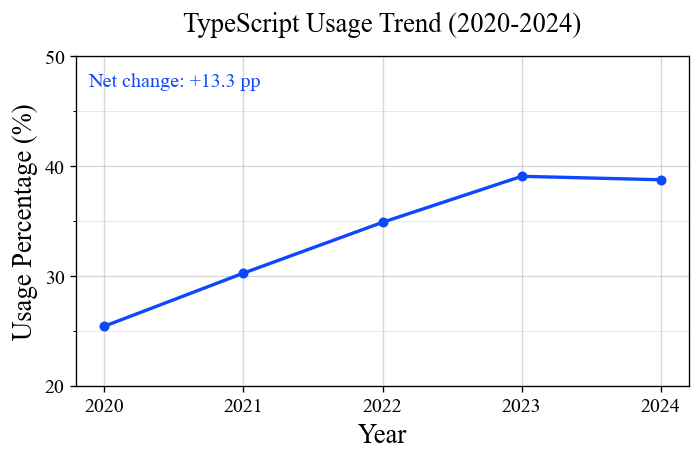

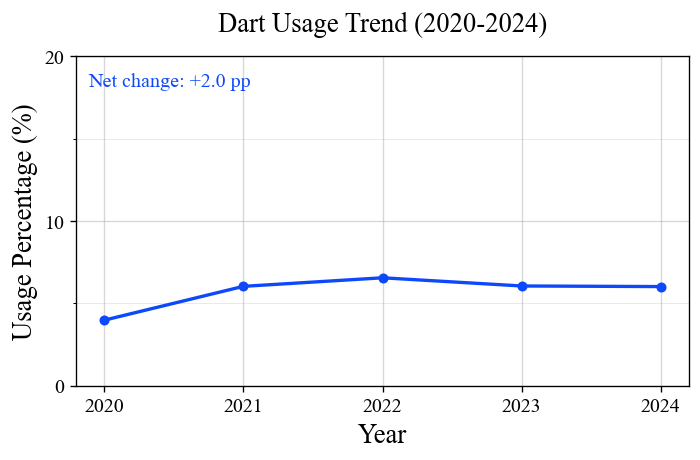

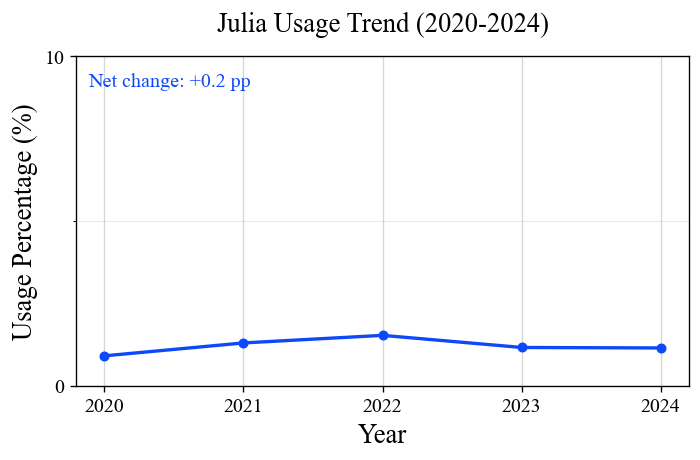

In [36]:
for lang in top_usage_positive:
    plotting.plot_single_language_trend(
        usage_trends_df,
        language=lang,
        metric_name="Usage"
    )


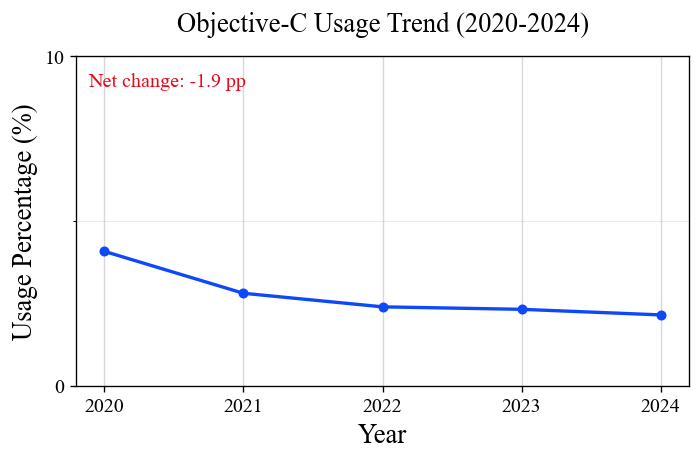

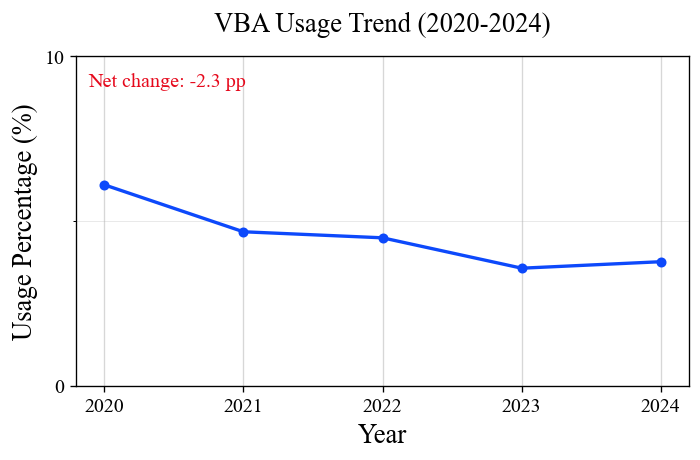

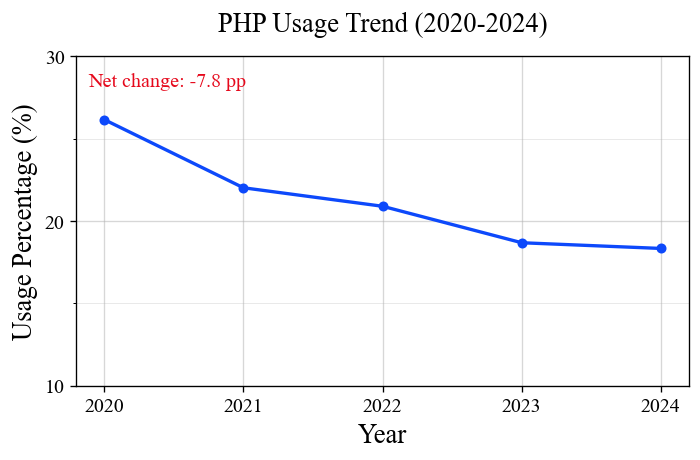

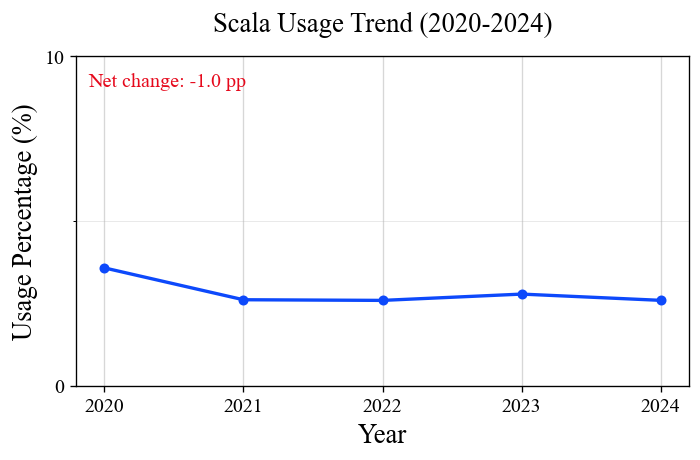

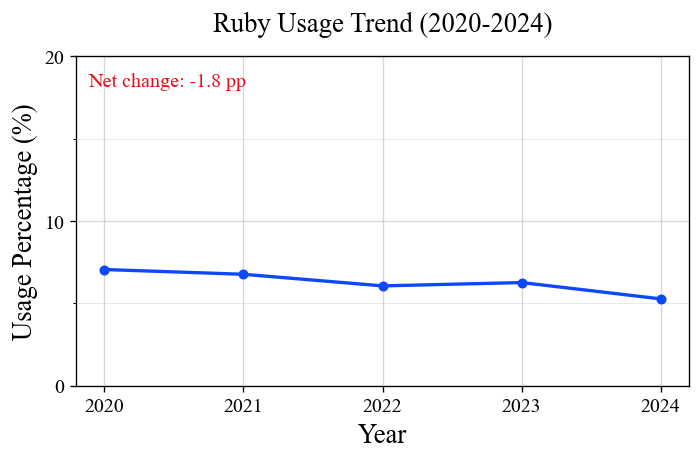

In [37]:
for lang in top_usage_negative:
    plotting.plot_single_language_trend(
        usage_trends_df,
        language=lang,
        metric_name="Usage"
    )

#### Desired Trends

In [43]:
top_desired_positive = (
    desired_measures_df["Relative Change (%)"]
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_desired_negative = (
    desired_measures_df["Relative Change (%)"]
    .sort_values()
    .head(5)
    .index
)

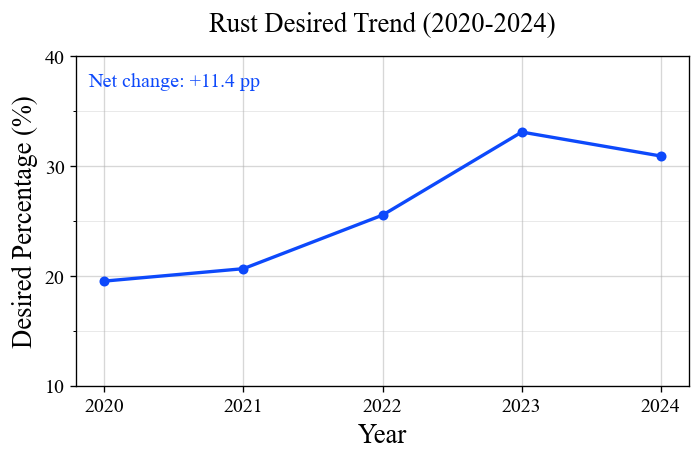

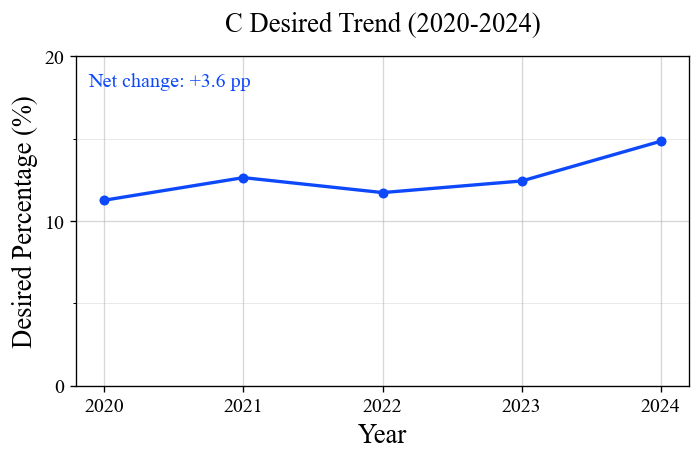

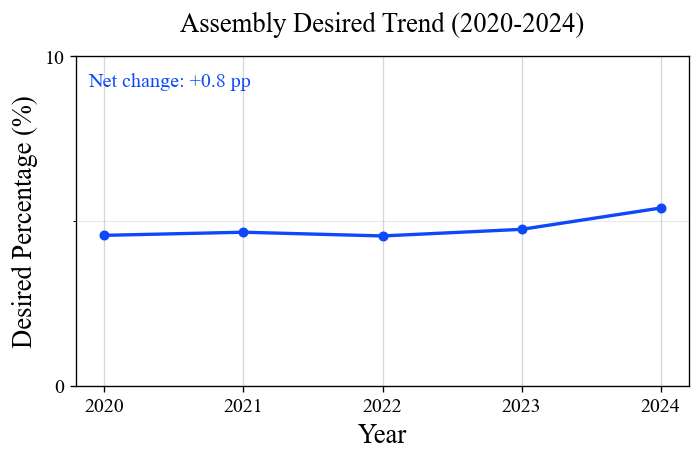

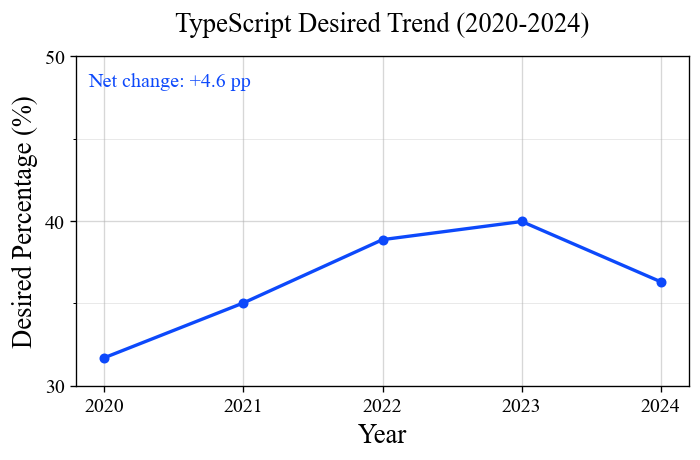

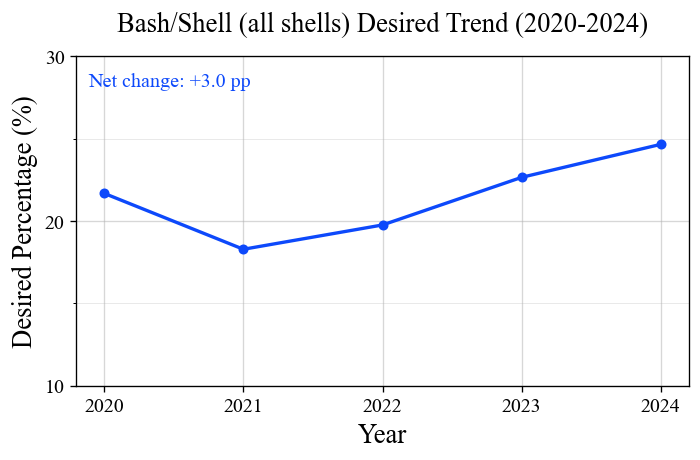

In [44]:
for lang in top_desired_positive:
    plotting.plot_single_language_trend(
        desired_trends_df,
        language=lang,
        metric_name="Desired"
    )

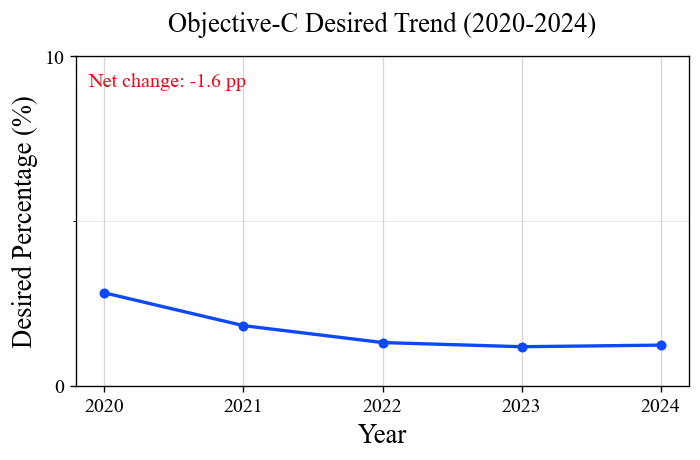

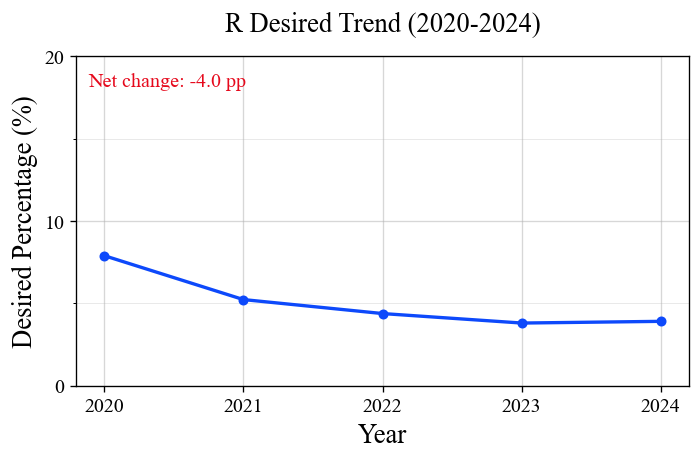

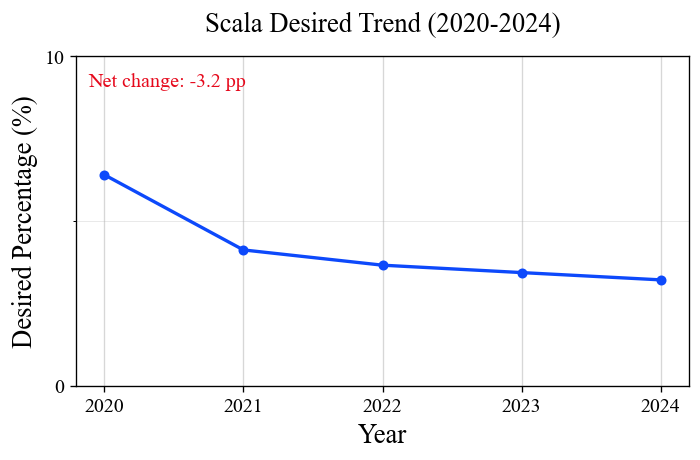

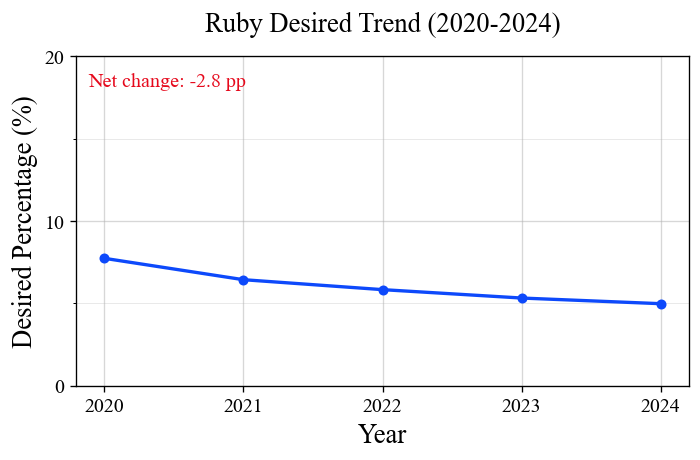

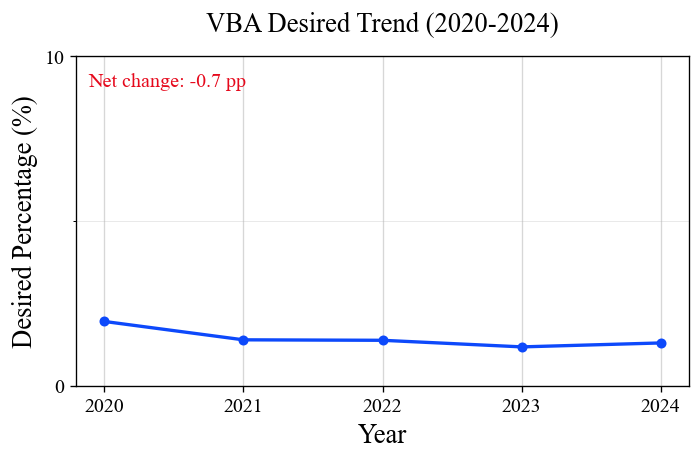

In [45]:
for lang in top_desired_negative:
    plotting.plot_single_language_trend(
        desired_trends_df,
        language=lang,
        metric_name="Desired"
    )

#### Loved/Admired Trends

In [46]:
top_admired_positive = (
    admired_measures_df["Relative Change (%)"]
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_admired_negative = (
    admired_measures_df["Relative Change (%)"]
    .sort_values()
    .head(5)
    .index
)

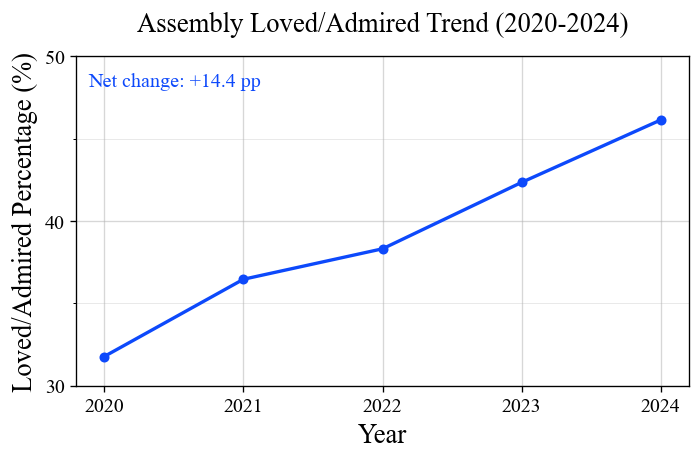

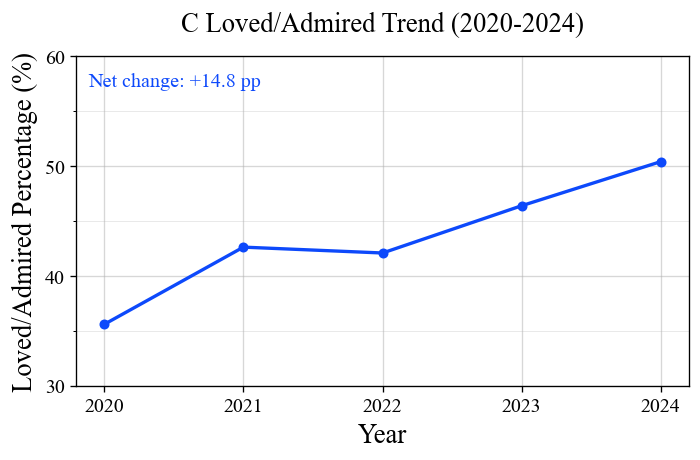

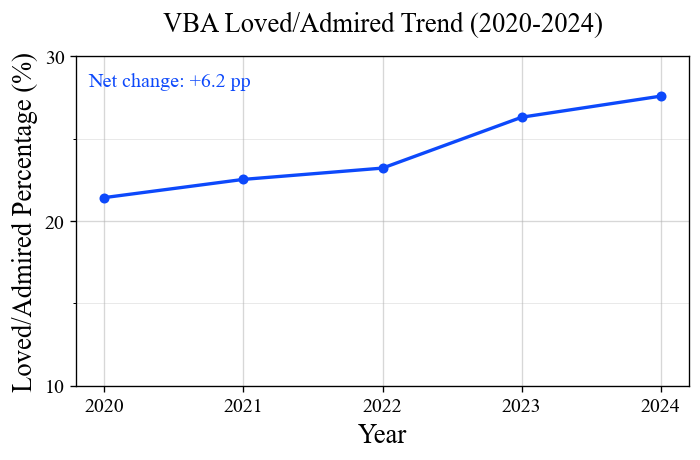

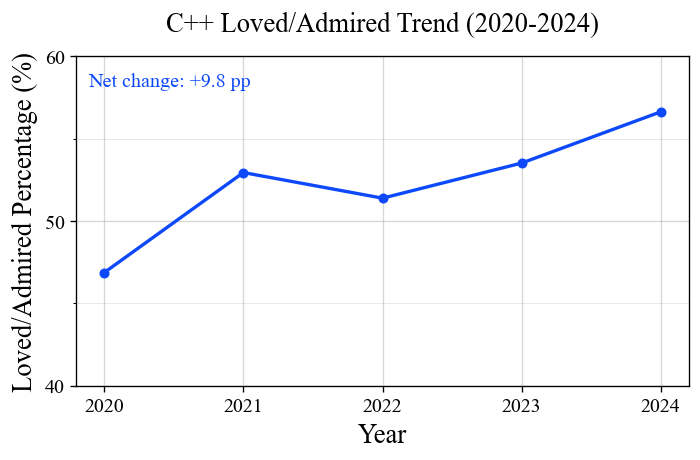

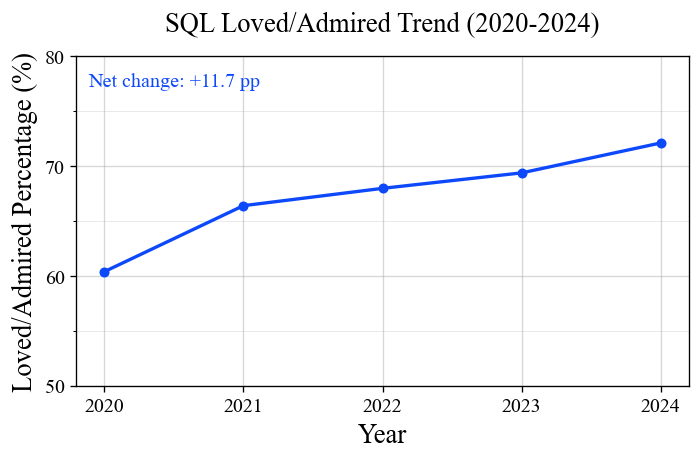

In [47]:
for lang in top_admired_positive:
    plotting.plot_single_language_trend(
        admired_trends_df,
        language=lang,
        metric_name="Loved/Admired"
    )

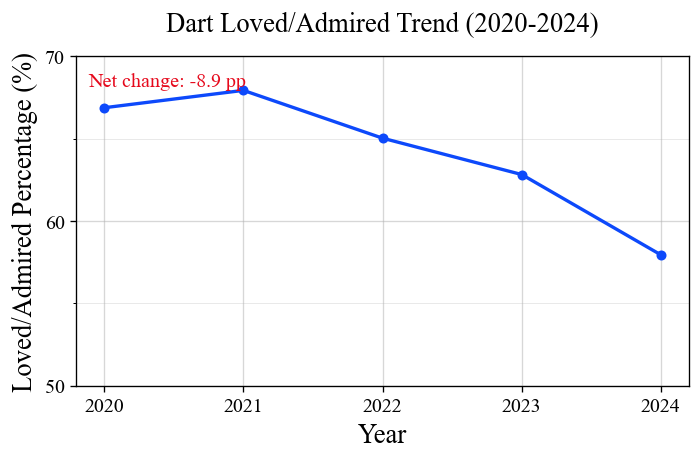

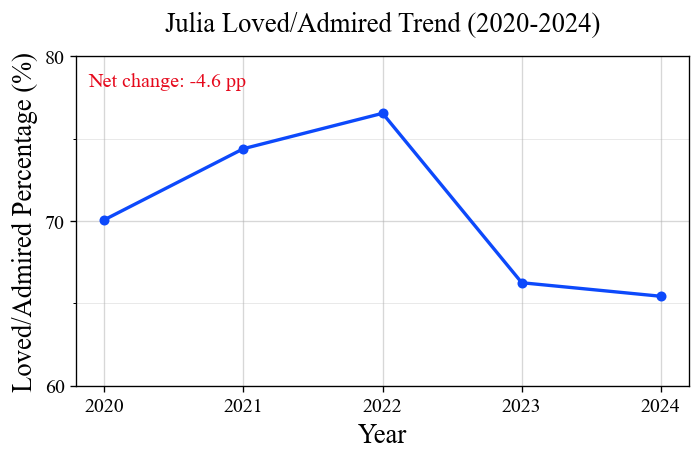

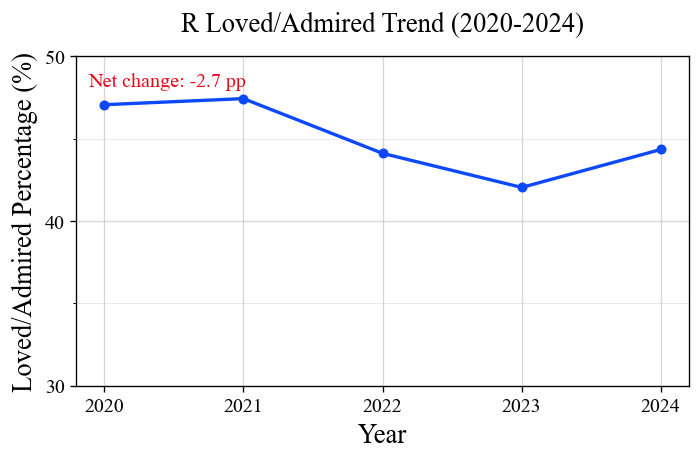

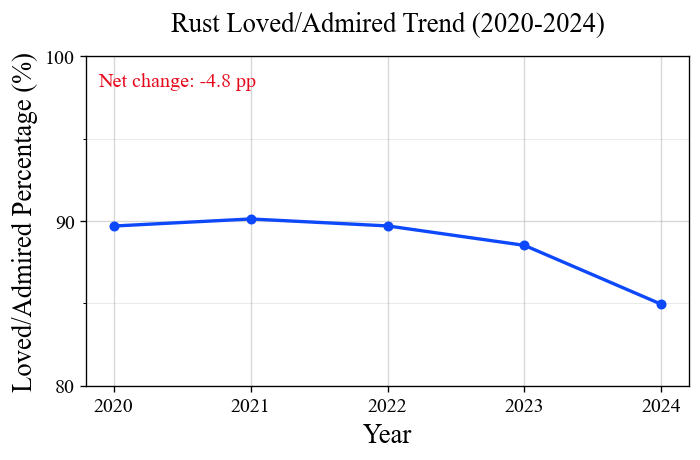

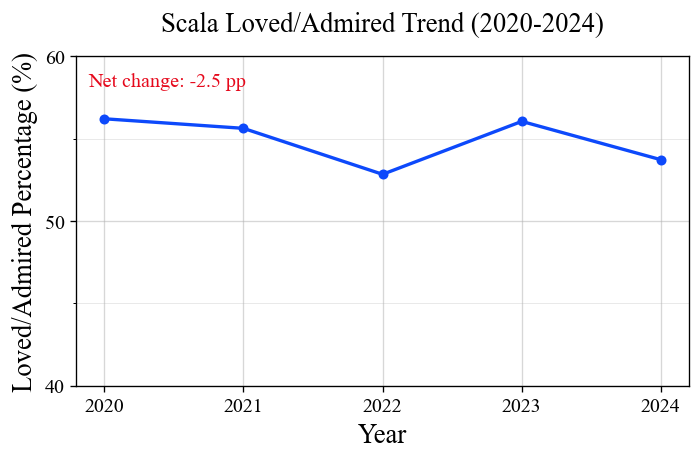

In [49]:
for lang in top_admired_negative:
    plotting.plot_single_language_trend(
        admired_trends_df,
        language=lang,
        metric_name="Loved/Admired"
    )